Text(0.5, 1.0, 'Diagrama de caja del número de marchas')

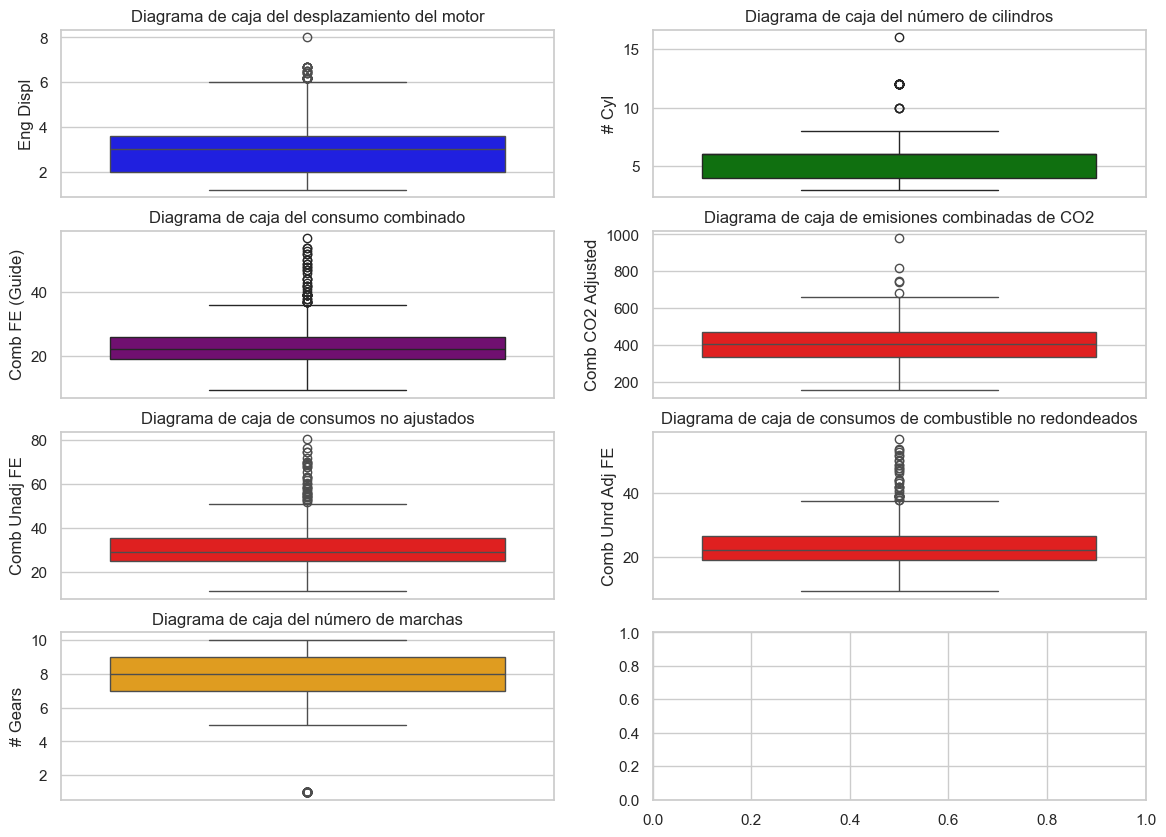

In [7]:
# Importar las bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import ConnectionPatch

# Configuración de estilo para las gráficas
sns.set(style="whitegrid")

# Cargar el archivo Excel
file_path = 'Base de datos experimento combustión exploratory.xlsx'

# Leer los datos de la hoja '24MY'
data = pd.read_excel(file_path, sheet_name='24MY')

# Inspeccionar las primeras filas de los datos
data.head()

# Crear subplots para las variables numéricas en formato de boxplot
fig, axs = plt.subplots(4, 2, figsize=(14, 10))

# Gráfica 1: Diagrama de caja del desplazamiento del motor
sns.boxplot(data=data, y='Eng Displ', ax=axs[0, 0], color='blue')
axs[0, 0].set_title('Diagrama de caja del desplazamiento del motor')

# Gráfica 2: Diagrama de caja del número de cilindros
sns.boxplot(data=data, y='# Cyl', ax=axs[0, 1], color='green')
axs[0, 1].set_title('Diagrama de caja del número de cilindros')

# Gráfica 3: Diagrama de caja del rendimiento en ciudad
sns.boxplot(data=data, y='Comb FE (Guide)', ax=axs[1, 0], color='purple')
axs[1, 0].set_title('Diagrama de caja del consumo combinado')

# Gráfica 4: Diagrama de caja de las emisiones combinadas de CO2
sns.boxplot(data=data, y='Comb CO2 Adjusted', ax=axs[1, 1], color='red')
axs[1, 1].set_title('Diagrama de caja de emisiones combinadas de CO2')

# Gráfica 5: Diagrama de caja de las emisiones combinadas de CO2
sns.boxplot(data=data, y='Comb Unadj FE', ax=axs[2, 0], color='red')
axs[2, 0].set_title('Diagrama de caja de consumos no ajustados')

# Gráfica 5: Diagrama de caja de las emisiones combinadas de CO2
sns.boxplot(data=data, y="Comb Unrd Adj FE", ax=axs[2, 1], color='red')
axs[2, 1].set_title('Diagrama de caja de consumos de combustible no redondeados')

# Gráfica 6: Diagrama de caja del número de marchas
sns.boxplot(data=data, y="# Gears", ax=axs[3, 0], color='orange')
axs[3, 0].set_title('Diagrama de caja del número de marchas')

In [8]:

# Seleccionar las columnas cuantitativas que vamos a analizar, incluyendo FE Rating
quantitative_columns = [
    'Eng Displ', '# Cyl', 'Comb FE (Guide)',
    'FE Rating (1-10 rating on Label)', 'Comb CO2 Adjusted', '# Gears', 'Comb Unadj FE', "Comb Unrd Adj FE"
]


# Calcular media, mediana, moda, y desviación estándar
mean_values = data[quantitative_columns].mean()
median_values = data[quantitative_columns].median()
mode_values = data[quantitative_columns].mode().iloc[0]  # Moda puede tener múltiples valores, tomamos el primero
std_values = data[quantitative_columns].std()

# Calcular percentiles específicos (25, 50, 75, 90)
percentiles = data[quantitative_columns].quantile([0.25, 0.50, 0.75, 0.90])

# Mostrar resultados
print("Media de los valores:\n", mean_values)
print("\nMediana de los valores:\n", median_values)
print("\nModa de los valores:\n", mode_values)
print("\nDesviación estándar de los valores:\n", std_values)
print("\nPercentiles (25, 50, 75, 90):\n", percentiles)

Media de los valores:
 Eng Displ                             3.055867
# Cyl                                 5.472482
Comb FE (Guide)                      23.257529
FE Rating (1-10 rating on Label)      4.573209
Comb CO2 Adjusted                   409.710280
# Gears                               7.747664
Comb Unadj FE                        31.191483
Comb Unrd Adj FE                     23.264109
dtype: float64

Mediana de los valores:
 Eng Displ                             3.00000
# Cyl                                 6.00000
Comb FE (Guide)                      22.00000
FE Rating (1-10 rating on Label)      5.00000
Comb CO2 Adjusted                   408.00000
# Gears                               8.00000
Comb Unadj FE                        29.08360
Comb Unrd Adj FE                     21.98075
dtype: float64

Moda de los valores:
 Eng Displ                             2.0000
# Cyl                                 4.0000
Comb FE (Guide)                      20.0000
FE Rating (1-10 rat

Una vez analizados los datos numéricos, ahora pasamos a los datos cualitativos:

NameError: name 'get_labels_with_percentages' is not defined

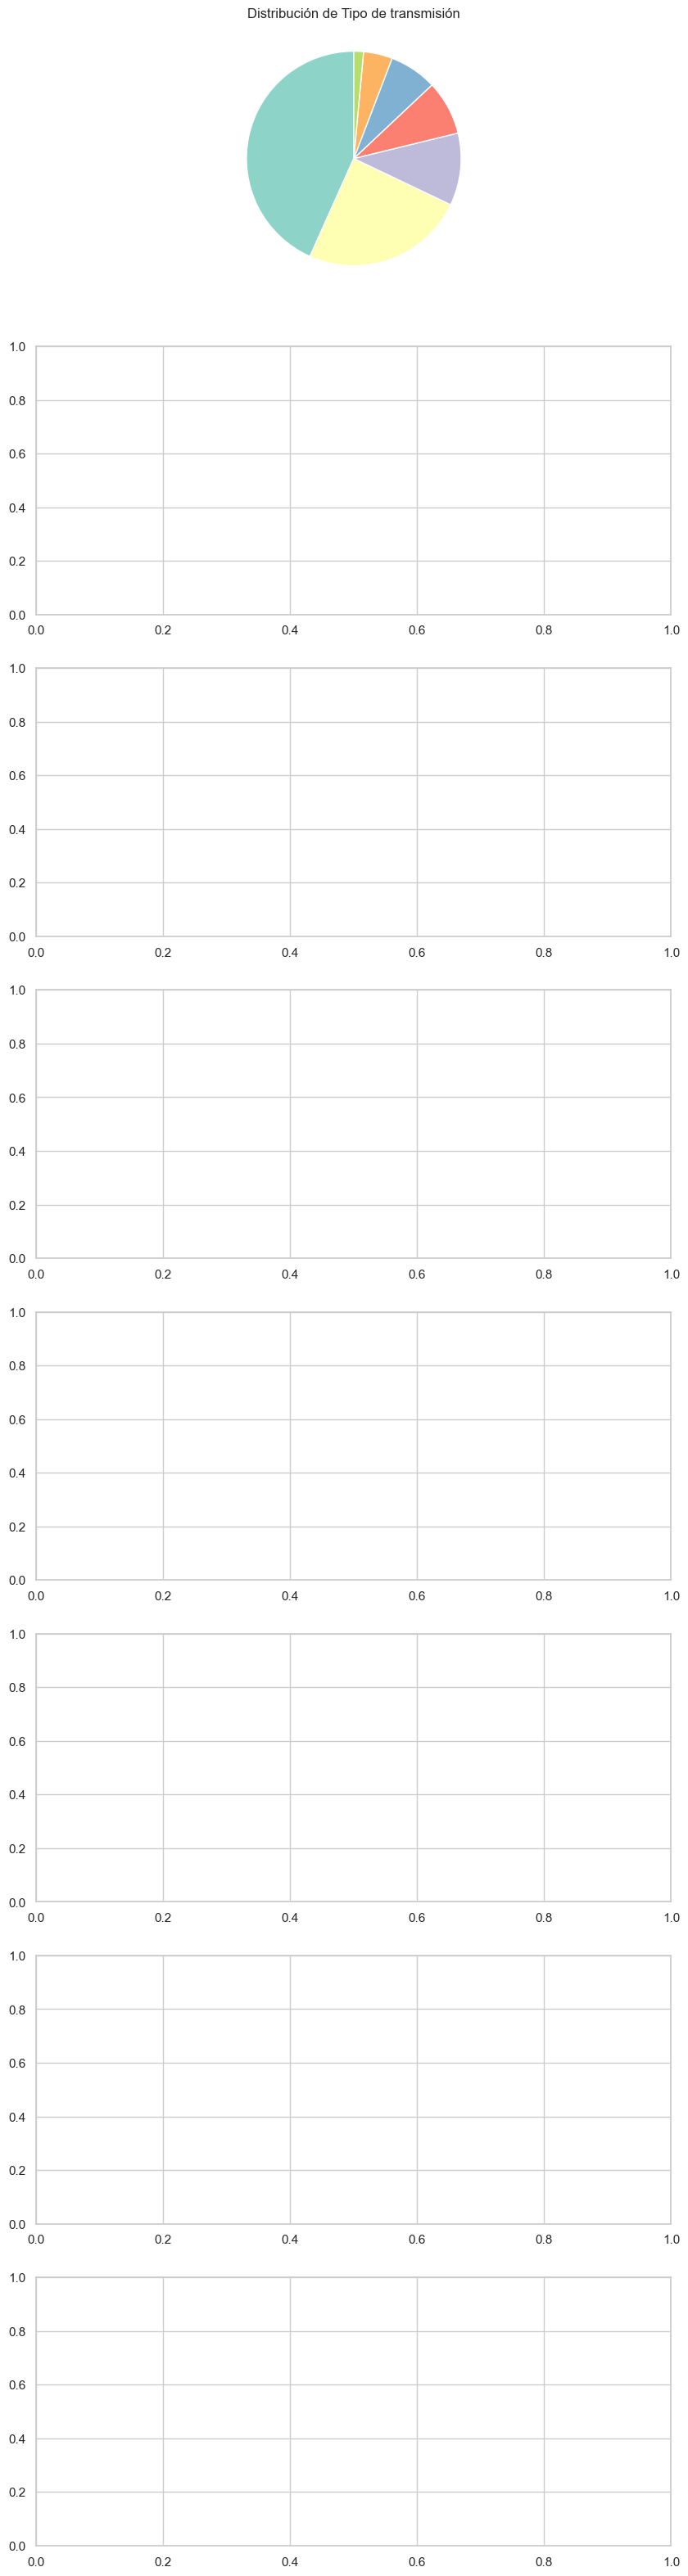

In [11]:
# Crear subplots para los ciclogramas (una columna, ocho filas)
fig, axs = plt.subplots(8, 1, figsize=(10, 40))  # Tamaño ajustado para acomodar los gráficos en una sola columna

# Gráfica 1: Ciclograma para 'Trans Desc' con colores diferenciados
trans_counts = data['Trans Desc'].value_counts()
trans_colors = sns.color_palette("Set3", len(trans_counts))  # Paleta 'cool' para Trans Desc
wedges1, texts1 = axs[0].pie(
    trans_counts, startangle=90, colors=trans_colors
)
axs[0].set_title('Distribución de Tipo de transmisión')
axs[0].legend(wedges1, get_labels_with_percentages(trans_counts), title="Trans Desc", loc='upper left', bbox_to_anchor=(1, 0.5))

# Gráfica 2: Ciclograma para 'Drive Desc' con colores diferenciados
drive_counts = data['Drive Desc'].value_counts()
drive_colors = sns.color_palette("Set1", len(drive_counts))  # Paleta 'Set1' para Drive Desc
wedges2, texts2 = axs[1].pie(
    drive_counts, startangle=90, colors=drive_colors
)
axs[1].set_title('Distribución de Tipo de tracción')
axs[1].legend(wedges2, get_labels_with_percentages(drive_counts), title="Drive Desc", loc='upper left', bbox_to_anchor=(1, 0.5))

# Gráfica 3: Ciclograma para '# Cyl' (Número de cilindros) con colores diferenciados
cyl_counts = data['# Cyl'].value_counts()
cyl_colors = sns.color_palette("Set2", len(cyl_counts))  # Paleta 'Set2' para # Cyl
wedges3, texts3 = axs[2].pie(
    cyl_counts, startangle=90, colors=cyl_colors
)
axs[2].set_title('Distribución del número de cilindros')
axs[2].legend(wedges3, get_labels_with_percentages(cyl_counts), title="# Cyl", loc='upper left', bbox_to_anchor=(1, 0.5))

# Gráfica 4: Ciclograma para 'FE Rating' con colores diferenciados
fe_rating_counts = data['FE Rating (1-10 rating on Label)'].value_counts()
fe_rating_colors = sns.color_palette("Set3", len(fe_rating_counts))  # Paleta 'Set3' para FE Rating
wedges4, texts4 = axs[3].pie(
    fe_rating_counts, startangle=90, colors=fe_rating_colors
)
axs[3].set_title('Distribución de FE Rating')
axs[3].legend(wedges4, get_labels_with_percentages(fe_rating_counts), title="FE Rating", loc='upper left', bbox_to_anchor=(1, 0.5))

# Gráfica 5: Ciclograma para 'Fuel Usage' (Tipo de combustible)
fuel_counts = data['Fuel Usage'].value_counts()
fuel_colors = ['blue' if fuel == 'Diesel, ultra low sulfur (15 ppm, maximum)' else sns.color_palette("Oranges")[i] for i, fuel in enumerate(fuel_counts.index)]
wedges5, texts5 = axs[4].pie(
    fuel_counts, startangle=90, colors=fuel_colors
)
axs[4].set_title('Distribución de tipos de combustible (Fuel Usage)')
axs[4].legend(wedges5, get_labels_with_percentages(fuel_counts), title="Fuel Usage", loc='upper left', bbox_to_anchor=(1, 0.5))

# Gráfica 6: Ciclograma para 'Type' (Convencional vs Híbrido)
type_counts = data['Descriptor - Model Type'].value_counts()
type_colors = ['blue', 'green']
type_labels = ['Convencional', 'Híbrido']
wedges6, texts6 = axs[5].pie(
    type_counts, startangle=90, colors=type_colors
)
axs[5].set_title('Distribución de vehículos convencionales vs híbridos')
axs[5].legend(wedges6, get_labels_with_percentages(type_counts, custom_labels=type_labels), title="Type", loc='upper left', bbox_to_anchor=(1, 0.5))

# Gráfica 7: Ciclograma para 'Guzzler?'
guzzler_counts = data['Guzzler? '].value_counts()
guzzler_colors = ['purple', 'red']
guzzler_labels = ['No sujeto a gas guzzler', 'Gas guzzler']
wedges7, texts7 = axs[6].pie(
    guzzler_counts, startangle=90, colors=guzzler_colors
)
axs[6].set_title('Vehículos sujetos a la tasa gas guzzler')
axs[6].legend(wedges7, get_labels_with_percentages(guzzler_counts, custom_labels=guzzler_labels), title="Guzzler?", loc='upper left', bbox_to_anchor=(1, 0.5))

# Gráfica 8: Ciclograma para 'Carline Class Desc'
carline_counts = data['Carline Class Desc'].value_counts()
carline_colors = sns.color_palette("Set2", len(carline_counts))
wedges8, texts8 = axs[7].pie(
    carline_counts, startangle=90, colors=carline_colors
)
axs[7].set_title('Distribución por tipo de categoría')
axs[7].legend(wedges8, get_labels_with_percentages(carline_counts), title="Tipo de categoría", loc='upper left', bbox_to_anchor=(1, 0.5))

# Ajustar espaciado
plt.tight_layout()
plt.subplots_adjust(hspace=0.6)  # Aumenta hspace para mayor separación entre los gráficos verticalmente

# Mostrar el gráfico
plt.show()


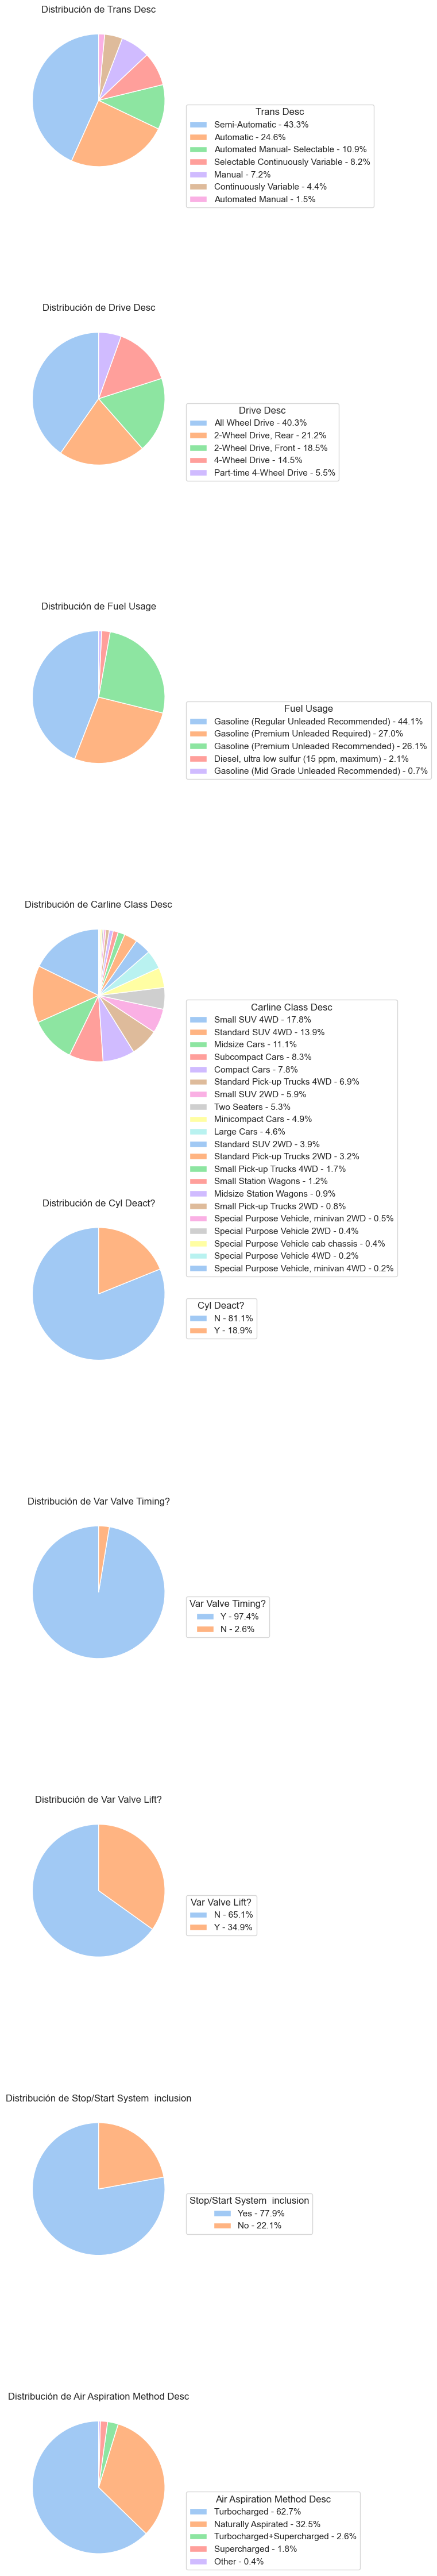

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cargar el archivo Excel
df_24MY = pd.read_excel(file_path, sheet_name='24MY')

# Definir columnas que ya se han graficado o que están relacionadas con el consumo
excluded_columns = [
    'Descriptor - Model Type', 'Guzzler?', 
    'City FE (Guide) - Conventional Fuel',
    'Hwy FE (Guide) - Conventional Fuel', 
    'Comb FE (Guide) - Conventional Fuel',
]

# Filtrar columnas que aún no se hayan graficado y no estén relacionadas con el consumo
columns_to_plot = [col for col in df_24MY.columns if col not in excluded_columns]

# Filtrar columnas categóricas para gráficos circulares
categorical_columns = df_24MY[columns_to_plot].select_dtypes(include='object').columns

# Crear gráficos circulares para las columnas categóricas faltantes (en una sola columna)
fig, axs = plt.subplots(len(categorical_columns), 1, figsize=(10, len(categorical_columns) * 5))

# Definir la función para generar leyenda con porcentajes
def get_labels_with_percentages(counts, custom_labels=None):
    total = counts.sum()
    if custom_labels:
        return [f'{label} - {count / total:.1%}' for label, count in zip(custom_labels, counts)]
    else:
        return [f'{label} - {count / total:.1%}' for label, count in zip(counts.index, counts)]

# Generar gráficos para cada columna categórica
for idx, column in enumerate(categorical_columns):
    counts = df_24MY[column].value_counts()
    colors = sns.color_palette("pastel", len(counts))
    
    wedges, texts = axs[idx].pie(counts, startangle=90, colors=colors)
    axs[idx].set_title(f'Distribución de {column}')
    axs[idx].legend(
        wedges, 
        get_labels_with_percentages(counts), 
        title=column, 
        loc='upper left', 
        bbox_to_anchor=(1, 0.5)
    )

# Ajustar espaciado entre subplots para mejor legibilidad
plt.tight_layout()
plt.subplots_adjust(hspace=0.8)  # Aumentar hspace para mayor separación entre gráficos

# Mostrar los gráficos
plt.show()


In [13]:
# Convertir variables categóricas a numéricas utilizando valores únicos para cada categoría
df_encoded = df_24MY.copy()
for column in categorical_columns:
    df_encoded[column] = df_encoded[column].astype('category').cat.codes

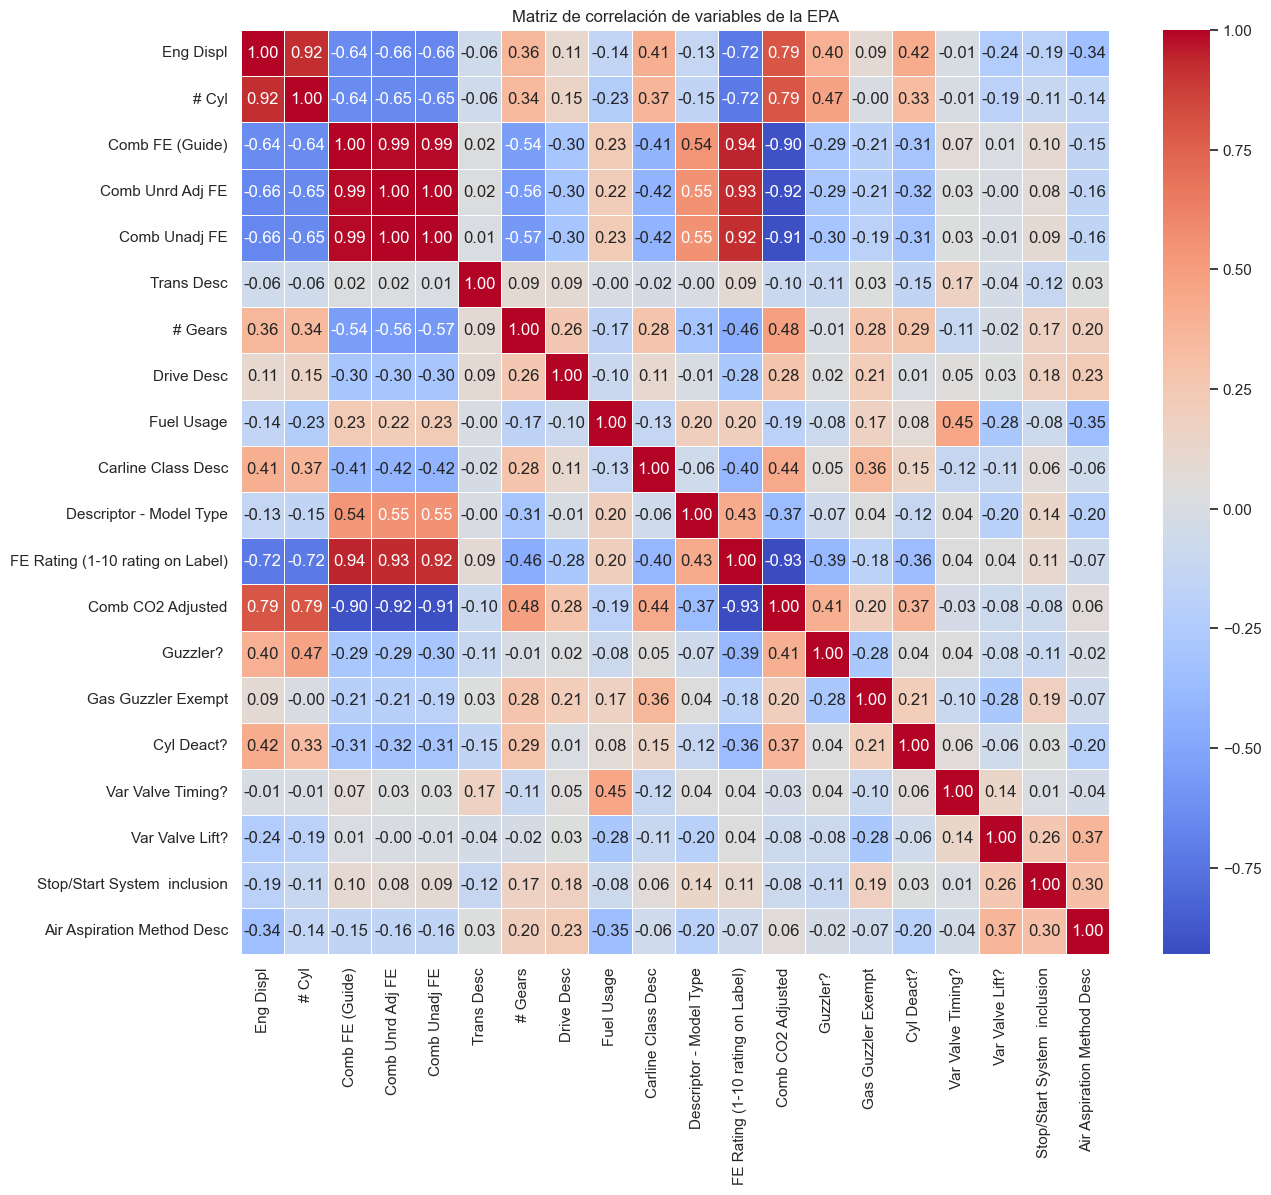

In [14]:
# Convertir columnas binarias con valores 'Yes', 'No', 'Y', 'N' a formato binario para las variables especificadas
binary_columns = ['Var Valve Lift?', 'Var Valve Timing?', 'Cyl Deact?', 'Stop/Start System  inclusion', 'Fuel Usage']
df_encoded[binary_columns] = df_encoded[binary_columns].replace({'Yes': 1, 'No': 0, 'Y': 1, 'N': 0})

# Convertir la columna 'Fuel Usage' en binaria (0 para Diesel, 1 para Gasolina)
df_encoded['Fuel Usage'] = df_encoded['Fuel Usage'].apply(lambda x: 0 if 'diesel' in str(x).lower() else 1 if 'gasolina' in str(x).lower() else x)

# Asegurarse de que todas las columnas sean de tipo numérico para el cálculo de correlación
df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce').fillna(0)

# Calcular la matriz de correlación con todas las columnas transformadas
correlation_matrix = df_encoded.corr().round(2)

# Graficar la matriz de correlación
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación de variables de la EPA' )
plt.show()

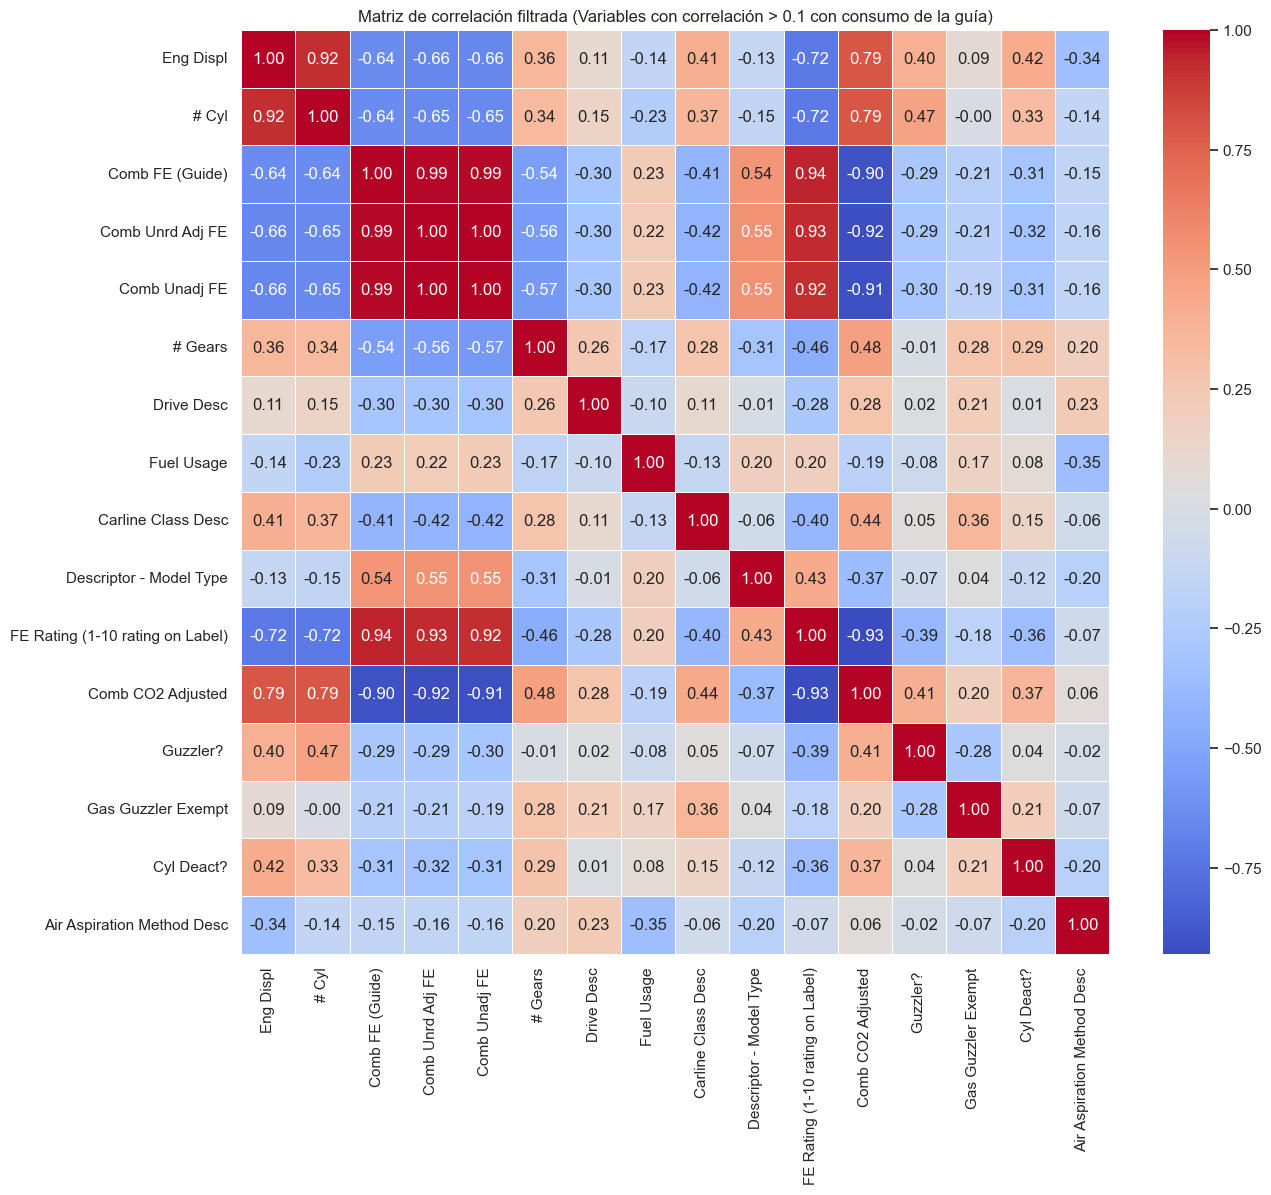

In [15]:

new_consumption_columns = ['Comb FE (Guide)']
filtered_columns = correlation_matrix[new_consumption_columns].apply(lambda x: x.abs() > 0.1).any(axis=1)
filtered_correlation_matrix = correlation_matrix.loc[filtered_columns, filtered_columns]

# Graficar la matriz de correlación filtrada
plt.figure(figsize=(14, 12))
sns.heatmap(filtered_correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación filtrada (Variables con correlación > 0.1 con consumo de la guía)')
plt.show()

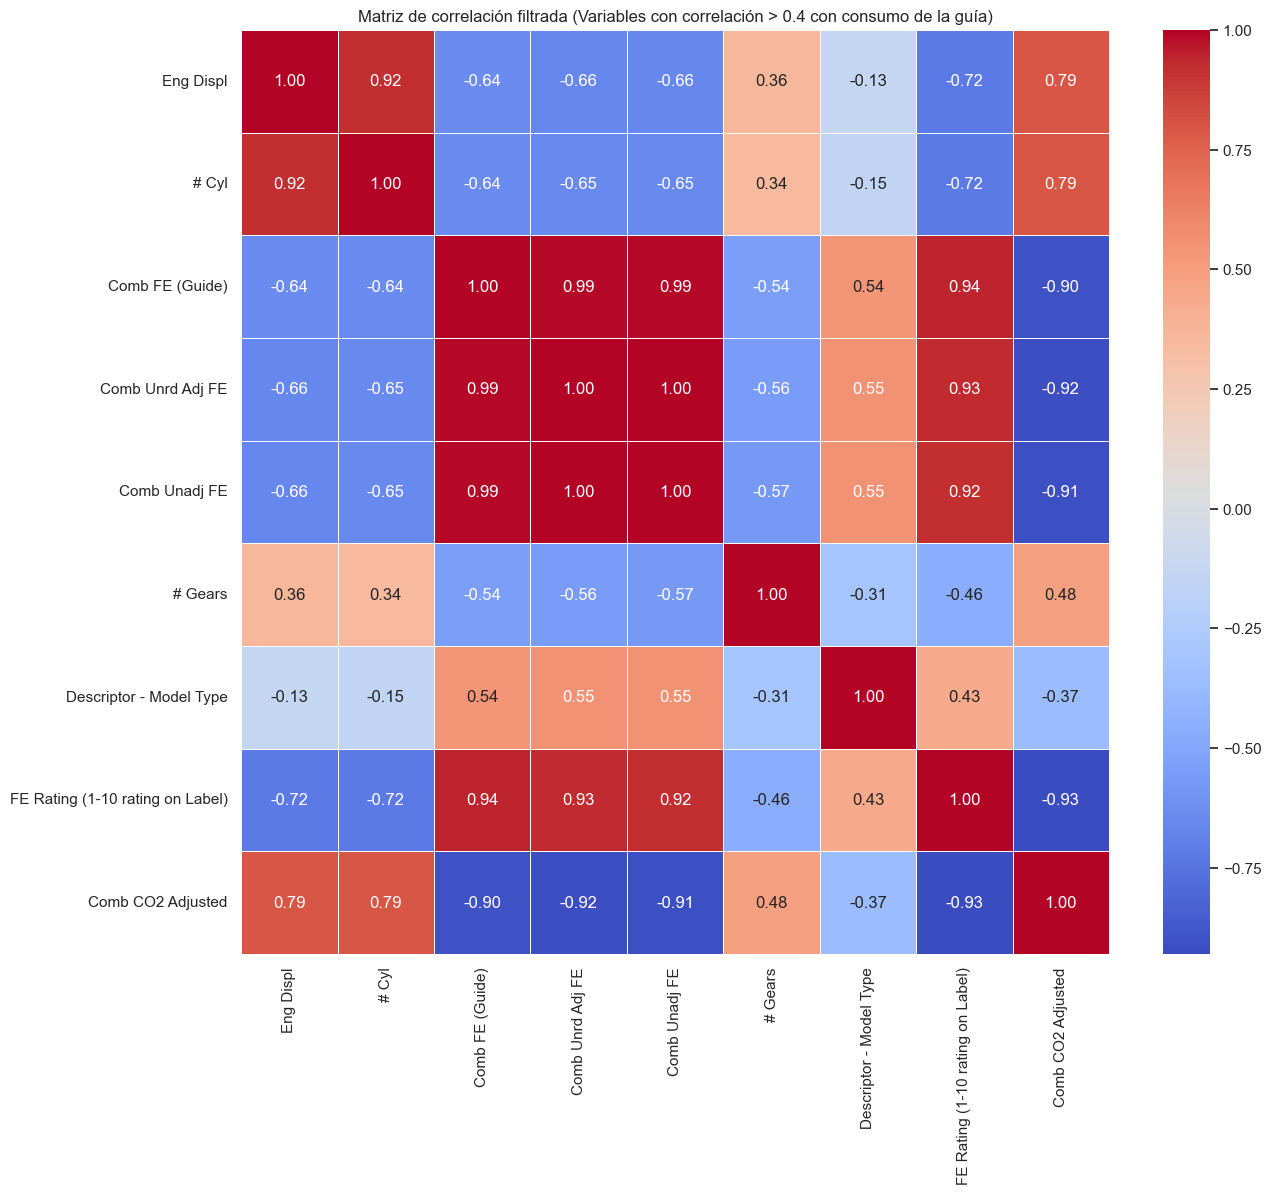

In [18]:
new_consumption_columns = ['Comb FE (Guide)']
filtered_columns = correlation_matrix[new_consumption_columns].apply(lambda x: x.abs() > 0.5).any(axis=1)
filtered_correlation_matrix = correlation_matrix.loc[filtered_columns, filtered_columns]

# Graficar la matriz de correlación filtrada
plt.figure(figsize=(14, 12))
sns.heatmap(filtered_correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación filtrada (Variables con correlación > 0.4 con consumo de la guía)')
plt.show()